<a href="https://colab.research.google.com/github/AlvinR21/Northstar-analysis/blob/main/data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from enum import unique
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load each file into a dataframe
customers = pd.read_csv('customers.csv')
drivers = pd.read_csv('drivers.csv')
vehicles = pd.read_csv('vehicles.csv')
hubs = pd.read_csv('hubs.csv')
orders = pd.read_csv('orders.csv')
deliveries = pd.read_csv('deliveries.csv')
incidents = pd.read_csv('incidents.csv')
complaints = pd.read_csv('complaints.csv')
app_events = pd.read_csv('app_events.csv')

In [2]:
#Show the first five rows of the deliveries table
deliveries.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22


In [3]:
# This is a dataframe display the summary of deliveries
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   delivery_id                    950 non-null    object 
 1   order_id                       950 non-null    object 
 2   driver_id                      950 non-null    object 
 3   vehicle_id                     950 non-null    object 
 4   hub_id                         950 non-null    object 
 5   dispatch_time                  950 non-null    object 
 6   delivery_completed_at          931 non-null    object 
 7   delivery_status                950 non-null    object 
 8   route_distance_km              950 non-null    float64
 9   manual_route_override_count    950 non-null    int64  
 10  proof_of_completion_missing    950 non-null    int64  
 11  customer_rating_post_delivery  936 non-null    float64
 12  fuel_or_charge_cost            950 non-null    flo

In [4]:
#Count missing values in deliveries
deliveries.isna().sum()

,0
delivery_id,0
order_id,0
driver_id,0
vehicle_id,0
hub_id,0
dispatch_time,0
delivery_completed_at,19
delivery_status,0
route_distance_km,0
manual_route_override_count,0


In [5]:
#Count missing values in customers
customers.isna().sum()

,0
customer_id,0
age,0
home_zone,0
customer_type,0
signup_date,0
loyalty_score,20
app_engagement_score,0
preferred_channel,13
account_status,0


In [6]:
#Count missing values in orders
orders.isna().sum()

,0
order_id,0
customer_id,0
service_type,0
order_created_at,0
promised_window_hours,0
pickup_zone,0
dropoff_zone,0
priority_level,0
order_value,0
booking_channel,25


In [7]:
#Show all unique values in the home_zone column of customers
customers['home_zone'].unique()

array(['North', 'AIRPORT', 'East', 'CENTRAL', 'Riverside', 'WEST',
       'north', 'South', 'West', 'Ctr', 'Airport', 'EAST', 'SOUTH',
       'RiverSide', 'NORTH', 'Central'], dtype=object)

In [8]:
#To count how many customers fall into each home_zone value
customers['home_zone'].value_counts()

,count
home_zone,
SOUTH,50
RiverSide,49
East,48
WEST,45
CENTRAL,44
West,43
South,42
Riverside,42
EAST,41


In [9]:
#Check zone values in orders pickup_zone
orders['pickup_zone'].unique()

#Check zone values in app_events zone_context
app_events['zone_context'].unique()

#Check zone values in drivers base_zone
drivers['base_zone'].unique()

array(['AIRPORT', 'Central', 'Airport', 'north', 'CENTRAL', 'North',
       'SOUTH', 'West', 'East', 'NORTH', 'EAST', 'WEST', 'Riverside',
       'South', 'RiverSide', 'Ctr'], dtype=object)

In [10]:
#This is the method that converts text to Title Case
customers['home_zone'] = customers['home_zone'].str.title()

customers['home_zone'].value_counts()

,count
home_zone,
North,111
South,92
Riverside,91
East,89
West,88
Central,77
Airport,69
Ctr,33


In [11]:
# Apply the same Title Case fix to all the other zone columns across tables
orders['pickup_zone'] = orders['pickup_zone'].str.title()
orders['dropoff_zone'] = orders['dropoff_zone'].str.title()
app_events['zone_context'] = app_events['zone_context'].str.title()
drivers['base_zone'] = drivers['base_zone'].str.title()
vehicles['assigned_zone'] = vehicles['assigned_zone'].str.title()

In [12]:
# This section shows that all zone columns are now title case only
print("customers home_zone:", customers['home_zone'].unique())
print("orders pickup_zone:", orders['pickup_zone'].unique())
print("app_events zone_context:", app_events['zone_context'].unique())

customers home_zone: ['North' 'Airport' 'East' 'Central' 'Riverside' 'West' 'South' 'Ctr']
orders pickup_zone: ['Airport' 'North' 'West' 'Riverside' 'Central' 'South' 'East' 'Ctr']
app_events zone_context: ['North' 'South' 'Airport' 'Central' 'West' 'Ctr' 'Riverside' 'East']


Decision 1
My first decision is standalised zone names to title case across all the table because zone names appeared 'AIRPORT', 'Airpot', and 'airpot'in different table or even the same table. This evidence showing Northstar's fragment data systems. Title case was chosen as the standard because it mathces the convention in the 'hubs' table.

In [13]:
orders['pickup_zone'] = orders['pickup_zone'].replace({'Ctr': 'Central'})
orders['pickup_zone'].unique()


array(['Airport', 'North', 'West', 'Riverside', 'Central', 'South',
       'East'], dtype=object)

In [14]:
orders['dropoff_zone'] = orders['dropoff_zone'].replace({'Ctr': 'Central'})
orders['dropoff_zone'].unique()

array(['South', 'Airport', 'North', 'East', 'Riverside', 'Central',
       'West'], dtype=object)

In [15]:
drivers['base_zone'] = drivers['base_zone'].replace({'Ctr': 'Central'})
drivers['base_zone'].unique()

array(['Airport', 'Central', 'North', 'South', 'West', 'East',
       'Riverside'], dtype=object)

In [16]:
vehicles['assigned_zone'] = vehicles['assigned_zone'].replace({'Ctr': 'Central'})
vehicles['assigned_zone'].unique()

array(['North', 'Airport', 'Riverside', 'West', 'Central', 'South',
       'East'], dtype=object)

In [17]:
app_events['zone_context'] = app_events['zone_context'].replace({'Ctr': 'Central'})
app_events['zone_context'].unique()

array(['North', 'South', 'Airport', 'Central', 'West', 'Riverside',
       'East'], dtype=object)

Decision 2 Map 'Ctr' to 'Central' in zone columns aross tables. 'Ctr' appeared as a seperate value with 33 customers, 'Ctr' is a short form of 'Central'. Title case alone could not fix this because the strings are genuienly different. Only a business knowledge mapping will resolve it. This short form problem is direct evidence of Northstar seperate business units capturing the same concept differently.

In [18]:
#To calculate the median of loyalty_score and fill any missing loyalty_score values with the median.
median_loyalty = customers['loyalty_score'].median()
print("Median loyalty score:", median_loyalty)
customers['loyalty_score'] = customers['loyalty_score'].fillna(median_loyalty)
print("Missing after fix:", customers['loyalty_score'].isna().sum())

Median loyalty score: 59.6
Missing after fix: 0


In [19]:
customers['preferred_channel'] = customers['preferred_channel'].fillna('Unknown')
print("Missing after fix:", customers['preferred_channel'].isna().sum())

Missing after fix: 0


In [20]:
orders['booking_channel'] = orders['booking_channel'].fillna('Unknown')
print("Missing after fix:", orders['booking_channel'].isna().sum())

Missing after fix: 0


In [21]:
#Use the median to fill missing traning_score values
median_training = drivers['training_score'].median()
print("Median training score:", median_training)
drivers['training_score'] = drivers['training_score'].fillna(median_training)
print("Missing after fix:", drivers['training_score'].isna().sum())

Median training score: 75.2
Missing after fix: 0


In [22]:
#Use the median to fill missing battery_health_pct values
median_battery = vehicles['battery_health_pct'].median()
print("Median battery health:", median_battery)
vehicles['battery_health_pct'] = vehicles['battery_health_pct'].fillna(median_battery)

print("Missing after fix:", vehicles['battery_health_pct'].isna().sum())

Median battery health: 78.05
Missing after fix: 0


In [23]:
#Use the median to fill missing reslove_hours values
median_resolved = incidents['resolved_hours'].median()
print("Median resolved hours:", median_resolved)

incidents['resolved_hours'] = incidents['resolved_hours'].fillna(median_resolved)

print("Missing after fix:", incidents['resolved_hours'].isna().sum())

Median resolved hours: 11.5
Missing after fix: 0


In [24]:
complaints['compensation_amount'] = complaints['compensation_amount'].fillna(0)

print("Missing after fix:", complaints['compensation_amount'].isna().sum())

Missing after fix: 0


Note: Deliveries and app_events missing values left intact
- delivery_completed_at(19 missing): These are deliveries that were never finished, which is probably what the data fragmentation case study is mentioning about.
- customer_rating_post_delivery(14 missing): The customer did not rate. Filling in the median would make up rating. we will only calculate 'rating averages' on rows that have rating.
- app_events['order_id'](144 missing): There is no order to many app events, like browsing. This is normal, there is no missing data.

Decision 3: In numeric columns, (loyalty_score, training_score, battery_health_pct, resolved_hours), filled the median becasue it is robust against extremee values. Same as text columns, (preferred_channel, booking_channel), filled with 'Unknown' as an explicit placeholder. Besides, the compensation_amount filled with 0 because missing values most likely represent 'no compensation paid', not unknown amount. Filling with median would inflate the average compensation per complaint. However, (delivery_completed_at, customer_rating_post_delivery, app_events.order_id), left as missing because they represent genuien real world absence such as incomplete deliveries, unrated journeys, browsing without an order etc. Filling them in would hire patterns the case study.

In [25]:
#Convert dispatch time from text to a proper datetime value
deliveries['dispatch_time'] = pd.to_datetime(deliveries['dispatch_time'])
print("dispatch_time dtype:", deliveries['dispatch_time'].dtype)

dispatch_time dtype: datetime64[ns]


In [26]:
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'])
print("delivery_completed_at dtype:", deliveries['delivery_completed_at'].dtype)

delivery_completed_at dtype: datetime64[ns]


In [27]:
orders['order_created_at'] = pd.to_datetime(orders['order_created_at'])
print("order_created_at dtype:", orders['order_created_at'].dtype)

order_created_at dtype: datetime64[ns]


In [28]:
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
print("signup_date dtype:", customers['signup_date'].dtype)

signup_date dtype: datetime64[ns]


In [29]:
vehicles['commission_date'] = pd.to_datetime(vehicles['commission_date'])
print("commission_date dtype:", vehicles['commission_date'].dtype)

commission_date dtype: datetime64[ns]


In [30]:
incidents['reported_at'] = pd.to_datetime(incidents['reported_at'])
print("reported_at dtype:", incidents['reported_at'].dtype)

reported_at dtype: datetime64[ns]


In [31]:
complaints['created_at'] = pd.to_datetime(complaints['created_at'])
print("created_at dtype:", complaints['created_at'].dtype)

created_at dtype: datetime64[ns]


In [32]:
app_events['event_timestamp'] = pd.to_datetime(app_events['event_timestamp'])
print("event_timestamp dtype:", app_events['event_timestamp'].dtype)

event_timestamp dtype: datetime64[ns]


In [33]:
duration = deliveries['delivery_completed_at'] - deliveries['dispatch_time']

deliveries['delivery_duration_hours'] = duration.dt.total_seconds() / 3600

deliveries[['dispatch_time', 'delivery_completed_at', 'delivery_duration_hours']].head()

,dispatch_time,delivery_completed_at,delivery_duration_hours
0,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,22.149973
1,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,-1.100000
2,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,1.108991
3,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,23.985584
4,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,4.042814


In [34]:
deliveries['delivery_duration_hours'].describe()

,delivery_duration_hours
count,931.000000
mean,9.545486
std,8.648622
min,-2.214477
25%,2.945854
50%,7.074356
75%,14.643664
max,43.456918


Decision 4: I discovered negative delivery durations flagged as data quality issues. After calculated delivery duration, some rows showd negative values which mean the delivery completed before it dispatched. This is impossible and comnfirm the case study's claim about fragmented systems producing inconsistent records. This is an invalid for analysis but I keep them visible to show it as evidence of the problem.

In [35]:
invalid_count = (deliveries['delivery_duration_hours'] <= 0).sum()
print("Deliveries with invalid duration:", invalid_count)

Deliveries with invalid duration: 64


In [36]:
deliveries = deliveries.merge(
    orders[['order_id', 'promised_window_hours']],
    on='order_id',
    how='left'
)
deliveries[['order_id', 'delivery_duration_hours', 'promised_window_hours']].head()

,order_id,delivery_duration_hours,promised_window_hours
0,O00938,22.149973,6
1,O00004,-1.100000,2
2,O00639,1.108991,2
3,O00313,23.985584,24
4,O00844,4.042814,6


In [37]:
deliveries['is_late'] = deliveries['delivery_duration_hours'] > deliveries['promised_window_hours']

deliveries['is_late'].value_counts()

,count
is_late,
False,515
True,435


In [38]:
deliveries['dispatch_day_of_week'] = deliveries['dispatch_time'].dt.day_name()

deliveries['dispatch_day_of_week'].value_counts()

,count
dispatch_day_of_week,
Friday,142
Tuesday,139
Thursday,137
Sunday,134
Saturday,134
Monday,132
Wednesday,132


In [40]:
deliveries = deliveries.merge(
    hubs[['hub_id', 'zone', 'hub_type']],
    on='hub_id',
    how='left'
)

deliveries = deliveries.rename(columns={'zone': 'hub_zone'})

deliveries[['delivery_id', 'hub_id', 'hub_zone', 'hub_type']].head()

,delivery_id,hub_id,hub_zone,hub_type
0,DL00001,H05,Central,Control
1,DL00002,H02,South,Dispatch
2,DL00003,H02,South,Dispatch
3,DL00004,H02,South,Dispatch
4,DL00005,H01,North,Dispatch


In [41]:
deliveries.groupby('hub_id')['is_late'].mean()

,is_late
hub_id,
H01,0.426471
H02,0.415094
H03,0.411765
H04,0.472441
H05,0.513043
H06,0.567308
H07,0.400000
H08,0.468750


In [42]:
hubs[hubs['hub_id'] == 'H06']

,hub_id,hub_name,zone,hub_type,capacity_score
5,H06,Airport Hub,Airport,Dispatch,71


HUB H06 shows the highest_late delviery late in the dataset, supporting the operations director's hypothesis that some hubs strucstures are underperform. Friday is the busiest dispatch day overall, suggesting workload concentration that may compound H06 issue.

In [45]:
import os
os.makedirs('data/clean', exist_ok=True)

customers.to_csv('data/clean/customers_clean.csv', index=False)
drivers.to_csv('data/clean/drivers_clean.csv', index=False)
vehicles.to_csv('data/clean/vehicles_clean.csv', index=False)
hubs.to_csv('data/clean/hubs_clean.csv', index=False)
orders.to_csv('data/clean/orders_clean.csv', index=False)
deliveries.to_csv('data/clean/deliveries_clean.csv', index=False)
incidents.to_csv('data/clean/incidents_clean.csv', index=False)
complaints.to_csv('data/clean/complaints_clean.csv', index=False)
app_events.to_csv('data/clean/app_events_clean.csv', index=False)

print("All 9 cleaned tables saved to data/clean/")

All 9 cleaned tables saved to data/clean/


In [47]:
!cd data && zip -r ../northstar_clean.zip clean

print("Created northstar_clean.zip — download from the file panel.")

updating: clean/ (stored 0%)
updating: clean/complaints_clean.csv (deflated 73%)
updating: clean/customers_clean.csv (deflated 74%)
updating: clean/app_events_clean.csv (deflated 72%)
updating: clean/deliveries_clean.csv (deflated 68%)
updating: clean/incidents_clean.csv (deflated 75%)
updating: clean/drivers_clean.csv (deflated 74%)
updating: clean/orders_clean.csv (deflated 75%)
updating: clean/vehicles_clean.csv (deflated 69%)
updating: clean/hubs_clean.csv (deflated 36%)
Created northstar_clean.zip — download from the file panel.


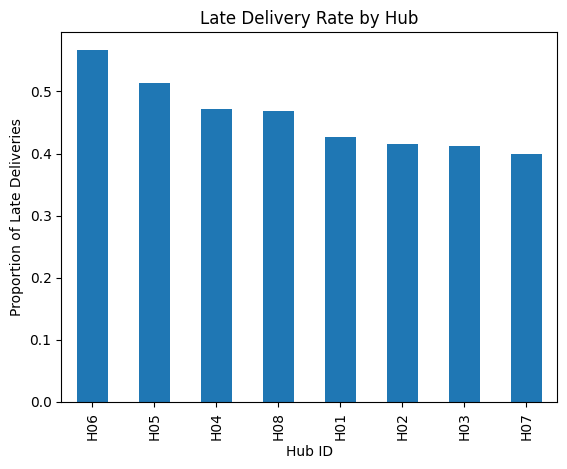

In [48]:
import matplotlib.pyplot as plt
late_by_hub = deliveries.groupby('hub_id')['is_late'].mean()
late_by_hub = late_by_hub.sort_values(ascending=False)

late_by_hub.plot(kind='bar')
plt.title('Late Delivery Rate by Hub')
plt.xlabel('Hub ID')
plt.ylabel('Proportion of Late Deliveries')

plt.show()